In [1]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload mode
%autoreload 2

In [2]:
import io
import pandas as pd
import numpy as np 
import json
import fsspec

import tqdm
import warnings

from matplotlib import pyplot as plt

# CoralNet Annotation EDA

In [3]:
df_annotations = pd.read_parquet("s3://dev-datamermaid-sm-sources/etl-outputs/coralnet/20260526_807b611/coralnet_training_resized_20260526_807b611.parquet")

In [4]:
df_annotations.head()

,source_id,image_id,row,col,coralnet_id,source_label_name,image_s3_key,load_width,load_height,uses_resized_image
0,23,12760,246,562,94,94,dev/images/resized/s23/images/12760.jpg,2048,1365,True
1,23,12760,282,1478,81,81,dev/images/resized/s23/images/12760.jpg,2048,1365,True
2,23,12760,298,554,94,94,dev/images/resized/s23/images/12760.jpg,2048,1365,True
3,23,12760,319,1104,81,81,dev/images/resized/s23/images/12760.jpg,2048,1365,True
4,23,12760,421,966,94,94,dev/images/resized/s23/images/12760.jpg,2048,1365,True


In [5]:
print(f"We currently have {df_annotations.shape[0]} annotations within {df_annotations['image_id'].nunique()} unique images across {df_annotations['source_id'].nunique()} sources.")

We currently have 20315787 annotations within 521008 unique images across 1294 sources.


## Update CoralNet Label ID's to CoralNet Label Names

In [6]:
s3_path = "s3://dev-datamermaid-sm-sources/coralnet-public-images/temporary/coralnet_id2name.json"

with fsspec.open(s3_path, "r") as f:
    coralnet_id2name = json.load(f)

/home/sagemaker-user/mermaid-segmentation/.venv/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


In [7]:
df_annotations["coralnet_name"] = df_annotations["coralnet_id"].map(lambda x: coralnet_id2name.get(str(x)))
df_annotations["source_label_name"] = df_annotations["coralnet_name"]

In [8]:
df_annotations["coralnet_id"].isna().sum(), df_annotations["source_label_name"].isna().sum()

(0, 907)

In [9]:
df_annotations[df_annotations["source_label_name"].isna()]["coralnet_id"].value_counts()

coralnet_id
2474    907
Name: count, dtype: int64

Interestingly the 2474 ID is mapped to None in the labelset mapping itself (rather than being missing in the mapping) - https://coralnet.ucsd.edu/label/2474/.    

## Explorations of the image sizes

There are 48392 images with a maximum size less than 2048.
There are 312 images with a maximum size less than or equal to 512.


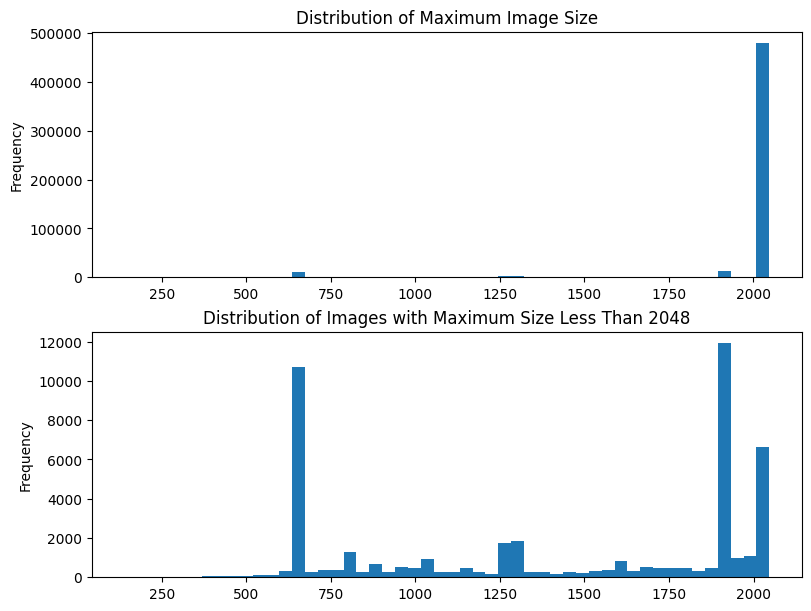

In [10]:
image_max_size = df_annotations.drop_duplicates(subset=["image_id"])[["load_width", "load_height"]].max(axis=1)

print(f"There are {(image_max_size<2048).sum()} images with a maximum size less than 2048.")
print(f"There are {(image_max_size<=512).sum()} images with a maximum size less than or equal to 512.")

fig, ax = plt.subplots(figsize = (8,6), nrows = 2, layout = "compressed")
image_max_size.plot.hist(bins=50, ax=ax[0])
ax[0].set_title("Distribution of Maximum Image Size")
image_max_size[image_max_size < 2048].plot.hist(bins=50, ax=ax[1])
ax[1].set_title("Distribution of Images with Maximum Size Less Than 2048")
plt.show()


The minimum width to height ratio is 0.1865234375.
The maximum width to height ratio is 7.501831501831502.


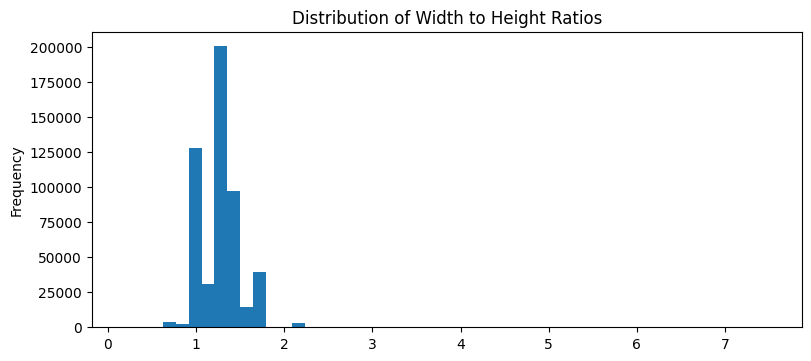

In [11]:
image_ratio = df_annotations.drop_duplicates(subset=["image_id"])[["load_width", "load_height"]].eval("load_width / load_height")

print(f"The minimum width to height ratio is {image_ratio.min()}.")
print(f"The maximum width to height ratio is {image_ratio.max()}.")

fig, ax = plt.subplots(figsize = (8,3.5), layout = "compressed")
image_ratio.plot.hist(bins=50, ax=ax)
ax.set_title("Distribution of Width to Height Ratios")
plt.show()

## Initial source subsetting

In [12]:
df_source = (
    df_annotations.groupby("source_id", as_index=False)
    .agg(
        image_count=("image_id", "nunique"),
        annotations_count=("coralnet_id", "size"),
        num_labels=("coralnet_name", "nunique"),
    )
)

In [13]:
num_images_threshold = 100
num_annotations_threshold = 1000

source_mask = ((df_source['image_count'] > num_images_threshold) & 
                                        (df_source['annotations_count'] >= num_annotations_threshold))
                                        
print(f"Sources with all updated (example) requirements (MERMAID): {source_mask.sum()}")

df_source.loc[source_mask,["image_count", "annotations_count"]].sum()

Sources with all updated (example) requirements (MERMAID): 486


image_count            496289
annotations_count    19292978
dtype: int64

In [14]:
source_min_requirement_list = df_source[source_mask]["source_id"].values.tolist()
df_annotations_subset = df_annotations[df_annotations["source_id"].isin(source_min_requirement_list)].reset_index(drop=True)

In [15]:
df_annotations_subset = df_annotations_subset[df_annotations_subset["source_id"].isin(source_min_requirement_list)].reset_index(drop=True)
print(f"After filtering based on the number of images and annotations, we currently have {df_annotations_subset.shape[0]} annotations within {df_annotations_subset['image_id'].nunique()} unique images across {df_annotations_subset['source_id'].nunique()} sources.")

After filtering based on the number of images and annotations, we currently have 19292978 annotations within 496289 unique images across 486 sources.


## Subset based on initial manual source assessment

In [16]:
df_source_quality = pd.read_csv("s3://dev-datamermaid-sm-sources/coralnet-public-images/temporary/coralnet_source_quality.csv") 
source_quality_list = df_source_quality[df_source_quality["ToKeep"]=="Yes"]["Source ID"].tolist()

In [17]:
df_annotations_subset = df_annotations_subset[df_annotations_subset["source_id"].isin(source_quality_list)].reset_index(drop=True)
print(f"After filtering for high-quality sources, we currently have {df_annotations_subset.shape[0]} annotations within {df_annotations_subset['image_id'].nunique()} unique images across {df_annotations_subset['source_id'].nunique()} sources.")

After filtering for high-quality sources, we currently have 3507090 annotations within 88833 unique images across 66 sources.


# Label Mappings Initialization

In [18]:
df_labels_coralnet = df_annotations_subset["source_label_name"].value_counts().reset_index()

## MERMAID Mapping

In [19]:
df_labelset100 = pd.read_csv("s3://dev-datamermaid-sm-sources/coralnet-public-images/temporary/mapped_to_mermaid_attributes.csv")
MERMAID_labelset = set(df_labelset100["name"].values)
df_labelset100_top = df_labelset100[df_labelset100["top100"]=="1"]

In [20]:
print(f"There are {len(MERMAID_labelset)} unique labels within the MERMAID label set, of which {len(df_labelset100_top)} are identified as high priority.")

There are 802 unique labels within the MERMAID label set, of which 109 are identified as high priority.


In [21]:
df_labelset100_top.head()

,id,created on,created by,updated on,updated by,status,name,CoralNetAnnotations,top100,priority,priority_notes,parent,Life history list,Region list
0,20090bf4-868e-431b-974c-ab9be5bbdb5f,2018-04-04 19:03:43.852250+00:00,NaN,2022-08-10 12:42:00.960645+00:00,NaN,superuser approved,Turf algae,7443962,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
1,b76bca12-884b-4404-bb9f-97d505b0fe58,2018-04-04 19:03:43.652901+00:00,NaN,2019-02-04 21:52:07.497930+00:00,NaN,superuser approved,Sand,3728358,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
2,09226989-50e7-4c40-bd36-5bcef32ee7a1,2018-04-04 19:03:43.100527+00:00,NaN,2019-02-04 21:52:07.522976+00:00,NaN,superuser approved,Macroalgae,2968785,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
3,f4df7abd-3d51-42fb-8cab-5102b95fad8e,2018-04-04 19:03:41.511370+00:00,NaN,2023-11-09 01:44:12.240717+00:00,NaN,superuser approved,Crustose coralline algae,1842258,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."
5,d9086647-3a82-4634-97bc-6e10347af39b,2018-04-04 19:03:43.623738+00:00,NaN,2018-04-04 19:03:43.623757+00:00,NaN,superuser approved,Bare substrate,1197412,1,1.0,top level category,NaN,NaN,"Central Indo-Pacific,Eastern Indo-Pacific,Trop..."


In [22]:
from mermaidseg.dataset_reconciliation import initialize_benthic_hierarchy
from mermaidseg.dataset_reconciliation.registry import roll_up_label

hierarchy_dict = initialize_benthic_hierarchy()
MERMAID_labelset_top100 = set(df_labelset100_top["name"].values)

mermaid_to_mermaid100_mapping = {}
for label in MERMAID_labelset:
    mermaid_to_mermaid100_mapping[label] = roll_up_label(label, hierarchy_dict, MERMAID_labelset_top100)

/home/sagemaker-user/mermaid-segmentation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## CoralNet to MERMAID

In [23]:
from mermaidseg.dataset_reconciliation import fetch_coralnet_to_mermaid
coralnet_to_mermaid_mapping = fetch_coralnet_to_mermaid()

In [24]:
df_labels_coralnet["mermaid_label"] = df_labels_coralnet["source_label_name"].map(coralnet_to_mermaid_mapping)

In [25]:
df_labels_coralnet["mermaid_top_100"] = df_labels_coralnet["mermaid_label"].map(mermaid_to_mermaid100_mapping)

## Source to Target Updated Mapping

In [26]:
df_mapping = pd.read_csv("../../../../configs/class_to_concepts.csv")
df_mapping = df_mapping[["source_label_class_name", "source_dataset_source", "target_label_class_name", "target_dataset_source"]].drop_duplicates()
df_mapping_coralnet = df_mapping[df_mapping["source_dataset_source"]=="coralnet"]

In [27]:
coralnet_to_mermaid_mapping_stt = {}
coralnet_to_mermaid_mapping_stt_dataset = {}

for i, row in df_mapping_coralnet.iterrows():
    target_label = row.target_label_class_name
    target_dataset = row.target_dataset_source
    while True:
        if target_dataset=="mermaid":
            coralnet_to_mermaid_mapping_stt[row.source_label_class_name] = target_label
            coralnet_to_mermaid_mapping_stt_dataset[row.source_label_class_name] = target_dataset
            break
        else:
            target_row = df_mapping[(df_mapping["source_label_class_name"]==target_label)*
                                    (df_mapping["source_dataset_source"]==target_dataset)]
            if target_row.shape[0]==0:
                coralnet_to_mermaid_mapping_stt[row.source_label_class_name] = target_label
                coralnet_to_mermaid_mapping_stt_dataset[row.source_label_class_name] = target_dataset
                break
            elif pd.isna(target_row.iloc[0]["target_dataset_source"]):
                coralnet_to_mermaid_mapping_stt[row.source_label_class_name] = target_label
                coralnet_to_mermaid_mapping_stt_dataset[row.source_label_class_name] = target_dataset
                break
            else:
                target_label = target_row.iloc[0]["target_label_class_name"]
                target_dataset = target_row.iloc[0]["target_dataset_source"]

In [28]:
print("Out of {} labels, {} are mapped to the mermaid dataset".format(len(coralnet_to_mermaid_mapping_stt_dataset), len([v for v in coralnet_to_mermaid_mapping_stt_dataset.values() if v=="mermaid"])))

Out of 1005 labels, 559 are mapped to the mermaid dataset


In [29]:
df_labels_coralnet["mermaid_stt"] = df_labels_coralnet["source_label_name"].apply(lambda x: coralnet_to_mermaid_mapping_stt.get(str(x).lower()))

# CoralNet Label EDA

In [30]:
df_labels_coralnet_eda = df_labels_coralnet.copy()
# df_labels_coralnet_eda = df_labels_coralnet_eda[df_labels_coralnet_eda["count"]>=500]

In [31]:
for column in ["source_label_name", "mermaid_label", "mermaid_top_100", "mermaid_stt"]:
    df_labels_coralnet_eda[column] = df_labels_coralnet_eda[column].apply(lambda x: str(x).lower())

cols = ["source_label_name", "mermaid_label", "mermaid_top_100", "mermaid_stt"]

df_labels_coralnet_eda[cols] = df_labels_coralnet_eda[cols].replace({
    "nan": None,
    "none": None,
    "None": None,
})

In [32]:
df_labels_coralnet_eda

,source_label_name,count,mermaid_label,mermaid_top_100,mermaid_stt
0,pavement,550302,other,None,hard substrate
1,turf algae,526312,turf algae,turf algae,turf algae
2,not coral,398492,None,None,other
3,cca (crustose coralline algae),227413,crustose coralline algae,crustose coralline algae,crustose coralline algae
4,acropora,205266,acropora,acropora,acropora alive
...,...,...,...,...,...
886,isopora old dead,1,None,None,None
887,manicina areolata,1,manicina areolata,faviidae,manicina areolata
888,diseased coral,1,hard coral,hard coral,other coral dead
889,bleached meandrina,1,None,None,None


In [33]:
print(f"The original coralnet dataset contains {df_labels_coralnet['source_label_name'].nunique()} unique labels")
# print(f"Once we filter by only including labels with 500+ instances, the coralnet dataset contains {df_labels_coralnet_eda['source_label_name'].nunique()} unique labels")

The original coralnet dataset contains 891 unique labels


## CoralNet API + Roll Up Label Mapping

In [34]:
print(f"Using the coralnet->mermaid API label mapping, the coralnet dataset contains {df_labels_coralnet_eda['mermaid_label'].nunique()} unique labels")
print(f"After the roll up to only hand-selected labels, the coralnet dataset contains {df_labels_coralnet_eda['mermaid_top_100'].nunique()} unique labels")

Using the coralnet->mermaid API label mapping, the coralnet dataset contains 250 unique labels
After the roll up to only hand-selected labels, the coralnet dataset contains 107 unique labels


In [35]:
annotation_count_sum = df_labels_coralnet_eda["count"].sum()
annotation_count_sum_filtered = df_labels_coralnet_eda[df_labels_coralnet_eda["mermaid_top_100"].isna()]["count"].sum()
print(f"In the mapping to the mermaid top 100 labels, we don't have a mapping for {df_labels_coralnet_eda['mermaid_top_100'].isna().sum()} out of {df_labels_coralnet_eda.shape[0]} labels, resulting in {annotation_count_sum_filtered} annotations remaining unmapped, which is {round(annotation_count_sum_filtered/annotation_count_sum*100, 2)}% of the dataset.")

In the mapping to the mermaid top 100 labels, we don't have a mapping for 520 out of 891 labels, resulting in 1159878 annotations remaining unmapped, which is 33.07% of the dataset.


In [36]:
df_labels_coralnet_eda[df_labels_coralnet_eda["mermaid_top_100"].isna()].head(10)

,source_label_name,count,mermaid_label,mermaid_top_100,mermaid_stt
0,pavement,550302,other,None,hard substrate
2,not coral,398492,None,None,other
16,shadow,33043,other,None,dark
20,encrusting algae,22093,None,None,algae covered substrate
35,turfy biotic matrix,9756,None,None,algae covered substrate
50,cca_knobby,5776,None,None,crustose coralline algae
53,ascidians,5623,ascidian,None,ascidian
56,out-planted colony,5244,None,None,hard coral alive
57,montipora grisea,5106,None,None,None
59,xenia cf crassa healthy,4858,None,None,None


## Jonathan's Mapping

In [37]:
print(f"Using Jonathan's label mapping, the coralnet dataset contains {df_labels_coralnet_eda['mermaid_stt'].nunique()} unique labels")

Using Jonathan's label mapping, the coralnet dataset contains 327 unique labels


In [38]:
annotation_count_sum = df_labels_coralnet_eda["count"].sum()
annotation_count_sum_filtered = df_labels_coralnet_eda[df_labels_coralnet_eda["mermaid_stt"].isna()]["count"].sum()
print(f"In the mapping to Jonathan's labels, we don't have mapping for {df_labels_coralnet_eda['mermaid_stt'].isna().sum()} out of {df_labels_coralnet_eda.shape[0]} labels, resulting in {annotation_count_sum_filtered} annotations remaining unmapped, which is {round(annotation_count_sum_filtered/annotation_count_sum*100, 2)}% of the dataset.")

In the mapping to Jonathan's labels, we don't have mapping for 314 out of 891 labels, resulting in 47045 annotations remaining unmapped, which is 1.34% of the dataset.


In [39]:
df_labels_coralnet_eda[df_labels_coralnet_eda["mermaid_stt"].isna()].head(10)

,source_label_name,count,mermaid_label,mermaid_top_100,mermaid_stt
48,dead coral with algae,5991,dead coral,bare substrate,None
49,madracis mirabilis,5817,madracis myriaster,madracis,None
57,montipora grisea,5106,None,None,None
59,xenia cf crassa healthy,4858,None,None,None
116,halisarca spp.,1953,None,None,None
142,stylophora wellsi,1449,None,None,None
149,pachyclavularia,1295,briareum,soft coral,None
150,thin plates raised skeletal,1287,None,None,None
163,monanchora arbuscula,1137,None,None,None
168,black fungus disease (bfd),1085,other,None,None


Differences between the two mappings

In [40]:
label_mask = df_labels_coralnet_eda["mermaid_label"].notna()*df_labels_coralnet_eda["mermaid_stt"].notna()
df_labels_coralnet_eda.loc[label_mask].loc[df_labels_coralnet_eda.loc[label_mask, "mermaid_label"]!=df_labels_coralnet_eda.loc[label_mask, "mermaid_stt"]]

,source_label_name,count,mermaid_label,mermaid_top_100,mermaid_stt
0,pavement,550302,other,None,hard substrate
4,acropora,205266,acropora,acropora,acropora alive
10,leather coral,58187,soft coral,soft coral,leather coral alive
11,pocillopora,53127,pocillopora,pocillopora,pocillopora alive
12,peyssonnelia,52196,peyssonnelid algae,crustose coralline algae,peyssonnelia
...,...,...,...,...,...
818,mud,2,silt,silt,sand
819,sponge: cliona,2,sponge,sponge,cliona
847,sabellidae,1,"worms, sabellid",None,sabellidae
878,rock_pavement,1,other,None,hard substrate


## Result: Update Missing Mermaid Maps with Jonathan's Mapping
In the meantime we also add a few select labels to the MermaidTop100 Labelset

In [41]:
manual_updates = {"hard substrate": "bare substrate",
                  "": None,
                  "hard coral alive": "hard coral",
                  "seriatopora alive": "seriatopora",
                  "transect line": "transect tools",
                  "pocillopora alive": "pocillopora",
                  "pocillopora dead": "pocillopora",
                  "acropora alive": "acropora",
                  }

to_add = ["dark", "algae covered substrate", "other coral bleached", "transect tools", 
          "other coral dead", "human-made structure", "background", "fish", "giant clam"]
important = ["dark", "transect tools", "background", "fish"]

MERMAID_labelset_top100_upd = MERMAID_labelset_top100.union(to_add)
MERMAID_labelset_top100_upd = set([label.lower() for label in MERMAID_labelset_top100_upd])
hierarchy_dict_lowercase = {k.lower() if k else None: v.lower() if v else None for k, v in hierarchy_dict.items()}

In [42]:
coralnet_to_mermaid_mapping_upd = {str(k).lower():str(v).lower() for k,v in coralnet_to_mermaid_mapping.items() if v is not None}
mermaid_to_mermaid100_mapping_upd = {str(k).lower():str(v).lower() for k,v in mermaid_to_mermaid100_mapping.items() if v is not None}

In [56]:
coralnet_to_mermaid_mapping_final = {}
for source_label_name in df_labels_coralnet_eda["source_label_name"].unique():
    map_flag = False
    if source_label_name in coralnet_to_mermaid_mapping_upd:
        mermaid_label = coralnet_to_mermaid_mapping_upd[source_label_name]
        mermaid_label = manual_updates.get(mermaid_label, mermaid_label)
        mermaid_label = roll_up_label(mermaid_label, hierarchy_dict_lowercase, MERMAID_labelset_top100_upd)
        if mermaid_label is not None:
            coralnet_to_mermaid_mapping_final[source_label_name] = mermaid_label
            map_flag = True
    if source_label_name in coralnet_to_mermaid_mapping_stt and not map_flag:
        jonathan_label = coralnet_to_mermaid_mapping_stt[source_label_name]
        jonathan_label = manual_updates.get(jonathan_label, jonathan_label)
        coralnet_to_mermaid_mapping_final[source_label_name] = roll_up_label(jonathan_label, hierarchy_dict_lowercase, MERMAID_labelset_top100_upd)
        map_flag = True
    if not map_flag:
        coralnet_to_mermaid_mapping_final[source_label_name] = None
coralnet_to_mermaid_mapping_final = {k:v.capitalize() if v is not None else None for k,v in coralnet_to_mermaid_mapping_final.items()}

In [58]:
with open("../../../../configs/coralnet_to_mermaid_mapping_temporary.json", "w") as f:
    json.dump(coralnet_to_mermaid_mapping_final, f)

In [45]:
df_labels_coralnet_eda["mermaid_final"] = df_labels_coralnet_eda["source_label_name"].apply(lambda x: coralnet_to_mermaid_mapping_final.get(str(x).lower()))

In [46]:
print(f"Using Jonathan's label mapping, the coralnet dataset contains {df_labels_coralnet_eda['mermaid_final'].nunique()} unique labels")

Using Jonathan's label mapping, the coralnet dataset contains 116 unique labels


In [47]:
annotation_count_sum = df_labels_coralnet_eda["count"].sum()
annotation_count_sum_filtered = df_labels_coralnet_eda[df_labels_coralnet_eda["mermaid_final"].isna()]["count"].sum()
print(f"In the final mapping, we don't have mapping for {df_labels_coralnet_eda['mermaid_final'].isna().sum()} out of {df_labels_coralnet_eda.shape[0]} labels, resulting in {annotation_count_sum_filtered} annotations remaining unmapped, which is {round(annotation_count_sum_filtered/annotation_count_sum*100, 2)}% of the dataset.")

In the final mapping, we don't have mapping for 386 out of 891 labels, resulting in 477339 annotations remaining unmapped, which is 13.61% of the dataset.


In [48]:
df_labels_coralnet_eda[df_labels_coralnet_eda["mermaid_final"].isna()].head(10)

,source_label_name,count,mermaid_label,mermaid_top_100,mermaid_stt,mermaid_final
2,not coral,398492,None,None,other,None
53,ascidians,5623,ascidian,None,ascidian,None
57,montipora grisea,5106,None,None,None,None
59,xenia cf crassa healthy,4858,None,None,None,None
62,palythoa caribaeorum,4705,palythoa caribaeorum,None,palythoa caribaeorum,None
66,unknown-19,4442,unknown,None,other,None
72,unknown,4048,unknown,None,unknown,None
81,low tide partial mortality,3457,None,None,other,None
88,xeniidae,3047,xeniidae,None,xeniidae,None
98,unknown-2,2486,unknown,None,other,None


In [49]:
count_sum_per_mermaid_final = (
    df_labels_coralnet_eda
    .groupby("mermaid_final", dropna=False)["count"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="count_sum")
    .rename(columns={"mermaid_final": "mermaid_final_label"})
)

count_sum_per_mermaid_final

,mermaid_final_label,count_sum
0,bare substrate,651317
1,turf algae,546144
2,NaN,477339
3,crustose coralline algae,306687
4,acropora,226655
...,...,...
112,faviidae,5
113,cycloseris,3
114,polyphyllia,3
115,acanthaster planci,2


# Map Annotations using Finalized Label Mapping

In [50]:
df_source_stats = (
    df_annotations.groupby("source_id", as_index=False)
    .agg(
        image_count=("image_id", "nunique"),
        annotations_count=("coralnet_id", "size"),
        num_labels=("coralnet_name", "nunique"),
    )
)

In [51]:
df_annotations_subset["mermaid_final"] = df_annotations_subset["source_label_name"].apply(lambda x: coralnet_to_mermaid_mapping_final.get(str(x).lower()))

In [52]:
df_annotations_subset.head()

,source_id,image_id,row,col,coralnet_id,source_label_name,image_s3_key,load_width,load_height,uses_resized_image,coralnet_name,mermaid_final
0,1645,1472493,451,753,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
1,1645,1472493,465,552,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
2,1645,1472493,524,997,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
3,1645,1472493,540,967,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
4,1645,1472493,583,317,62,Favia (Indo-Pacific),dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Favia (Indo-Pacific),favia


In [53]:
df_labels = df_annotations_subset.groupby("mermaid_final", as_index=False).agg(
    num_annotations=("mermaid_final", "size"),
    num_images=("image_id", "nunique"),
    num_sources=("source_id", "nunique"),
)

df_labels

,mermaid_final,num_annotations,num_images,num_sources
0,acanthaster planci,2,2,2
1,acanthastrea,1421,1003,38
2,acropora,226655,33709,51
3,acropora cervicornis,81,26,4
4,acropora palmata,54,10,2
...,...,...,...,...
111,tubipora,51,13,9
112,turbinaria-algae,1498,531,13
113,turbinaria-coral,5493,1484,41
114,turf algae,546144,41421,35


## Final label subsetting

In [54]:
num_images_threshold = 100
num_annotations_threshold = 500
num_sources_threshold = 3
df_labels_subset = df_labels[(df_labels["num_annotations"] >= num_annotations_threshold)*
                             (df_labels["num_images"] >= num_images_threshold)*
                             (df_labels["num_sources"] >= num_sources_threshold)]
df_labels_subset

,mermaid_final,num_annotations,num_images,num_sources
1,acanthastrea,1421,1003,38
2,acropora,226655,33709,51
6,agaricia agaricites,1899,392,7
10,algae covered substrate,31849,4188,4
11,alveopora,1172,112,16
...,...,...,...,...
109,tridacna giant clam,634,473,16
112,turbinaria-algae,1498,531,13
113,turbinaria-coral,5493,1484,41
114,turf algae,546144,41421,35


In [55]:
df_labels_subset.describe()

,num_annotations,num_images,num_sources
count,76.000000,76.000000,76.000000
mean,39622.263158,6235.644737,32.013158
std,105876.123110,9558.325009,16.700893
min,501.000000,112.000000,3.000000
25%,1884.750000,606.750000,16.000000
50%,5161.500000,2119.000000,36.000000
75%,21378.500000,6875.000000,45.250000
max,651317.000000,41421.000000,62.000000


In [56]:
print([label.capitalize() for label in df_labels_subset["mermaid_final"].values])

['Acanthastrea', 'Acropora', 'Agaricia agaricites', 'Algae covered substrate', 'Alveopora', 'Astrea', 'Astreopora', 'Background', 'Bare substrate', 'Coscinaraea', 'Crustose coralline algae', 'Cyanobacteria', 'Cyphastrea', 'Dark', 'Dictyota', 'Diploastrea', 'Dipsastraea', 'Echinophyllia', 'Echinopora', 'Euphyllia', 'Favia', 'Favites', 'Fungia', 'Galaxea', 'Gardineroseris', 'Goniastrea', 'Goniopora', 'Gorgonian', 'Halimeda', 'Hard coral', 'Heliopora', 'Human-made structure', 'Hydnophora', 'Isopora', 'Leptastrea', 'Leptoria', 'Leptoseris', 'Lobophora', 'Lobophyllia', 'Macroalgae', 'Madracis', 'Merulina', 'Millepora', 'Montastraea', 'Montastraea cavernosa', 'Montipora', 'Mycedium', 'Orbicella annularis', 'Orbicella faveolata', 'Pachyseris', 'Padina', 'Pavona', 'Pectinia', 'Platygyra', 'Pocillopora', 'Porites', 'Porites astreoides', 'Psammocora', 'Rock', 'Rubble', 'Sand', 'Sargassum', 'Sea urchin', 'Seagrass', 'Seriatopora', 'Siderastrea siderea', 'Soft coral', 'Sponge', 'Stylophora', 'Symp

In [57]:
df_source_labels_eligible = (
    df_annotations_subset
    .dropna(subset=["mermaid_final"])
    .groupby(["mermaid_final", "source_id"], as_index=False)
    .agg(
        num_annotations=("image_id", "size"),
        num_images=("image_id", "nunique"),
    )
    .sort_values(["mermaid_final", "num_annotations"], ascending=[True, False])
    .reset_index(drop=True)
)

df_source_labels_eligible.head()

,mermaid_final,source_id,num_annotations,num_images
0,acanthaster planci,4710,1,1
1,acanthaster planci,4721,1,1
2,acanthastrea,6053,256,30
3,acanthastrea,7116,152,98
4,acanthastrea,6855,83,72


In [58]:
df_source_labels_eligible = df_source_labels_eligible[df_source_labels_eligible["mermaid_final"].isin(df_labels_subset["mermaid_final"])]
df_source_labels_eligible

,mermaid_final,source_id,num_annotations,num_images
2,acanthastrea,6053,256,30
3,acanthastrea,7116,152,98
4,acanthastrea,6855,83,72
5,acanthastrea,6868,83,72
6,acanthastrea,6924,83,72
...,...,...,...,...
2716,zoanthid,2978,2,2
2717,zoanthid,3425,2,1
2718,zoanthid,6722,2,2
2719,zoanthid,3363,1,1


In [59]:
df_source_labels_eligible[["mermaid_final", "source_id"]].nunique()

mermaid_final    76
source_id        66
dtype: int64

In [60]:
print("We are finally left with", df_source_labels_eligible[["num_annotations"]].sum().item(), "annotations and", 
df_source_labels_eligible[["mermaid_final"]].nunique().item(), "labels and", df_source_labels_eligible[["source_id"]].nunique().item(), "sources.")

We are finally left with 3011292 annotations and 76 labels and 66 sources.


In [61]:
df_source_labels_eligible.groupby('source_id')[['num_annotations']].sum().describe()

,num_annotations
count,66.000000
mean,45625.636364
std,51021.479617
min,2053.000000
25%,10298.250000
50%,24517.000000
75%,67111.250000
max,242985.000000


# Split Optimization

In [62]:
import numpy as np
import pandas as pd
from collections import defaultdict

def constrained_stratified_group_split_from_aggregated(
    df_agg,
    source_col='Source ID',
    label_col='Label ID',
    count_col='Num Annotations',  # or 'Num Images' depending on what you want to balance
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    n_iterations=5000,
    random_state=42,
    verbose=True
):
    """
    Split pre-aggregated dataset with:
    - No source leakage across splits
    - Stratified labels based on annotation counts
    - Respects source-level grouping
    
    Parameters:
    -----------
    df_agg : pd.DataFrame
        Pre-aggregated dataframe with columns: source, label, count
    source_col : str
        Column identifying unique sources (e.g., 'Source ID')
    label_col : str
        Column with target labels (e.g., 'Label ID')
    count_col : str
        Column with counts to balance (e.g., 'Num Annotations')
    train_ratio, val_ratio, test_ratio : float
        Desired split proportions (should sum to 1)
    n_iterations : int
        Number of random assignments to try (more = better balance)
    random_state : int
        Random seed for reproducibility
    verbose : bool
        Print progress and statistics
    """
    np.random.seed(random_state)
    
    # Validate inputs
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-10, "Ratios must sum to 1"
    
    # 1. Get unique sources and labels
    sources = df_agg[source_col].unique()
    unique_labels = df_agg[label_col].unique()
    n_sources = len(sources)
    n_labels = len(unique_labels)
    
    if verbose:
        print(f"Found {n_sources} unique sources")
        print(f"Found {n_labels} unique labels")
        print(f"Total {count_col}: {df_agg[count_col].sum():,}")
    
    # 2. Create source-label count matrix
    # Initialize matrix: sources × labels
    label_matrix = np.zeros((n_sources, n_labels))
    source_to_idx = {source: i for i, source in enumerate(sources)}
    # Reorder labels by rarity (rare labels first) to help the optimizer
    label_source_counts = (
        df_agg.groupby(label_col)[source_col]
        .nunique()
        .reindex(unique_labels, fill_value=0)
    )
    unique_labels = label_source_counts.sort_values().index.to_numpy()
    label_to_idx = {label: j for j, label in enumerate(unique_labels)}

    # Hard feasibility check:
    # with group-based splitting, each label must exist in >= 3 different sources
    # to be present in train/val/test simultaneously.
    impossible_labels = label_source_counts[label_source_counts < 3]
    if not impossible_labels.empty:
        preview = ", ".join(
            f"{lbl} ({cnt} sources)" for lbl, cnt in impossible_labels.head(10).items()
        )
        raise ValueError(
            "Cannot guarantee every label in every split. "
            f"These labels appear in fewer than 3 sources: {preview}"
            + (" ..." if len(impossible_labels) > 10 else "")
        )
    
    for _, row in df_agg.iterrows():
        i = source_to_idx[row[source_col]]
        j = label_to_idx[row[label_col]]
        label_matrix[i, j] = row[count_col]
    
    # 3. Calculate source sizes (total annotations per source)
    source_sizes = label_matrix.sum(axis=1)
    
    # 4. Calculate global label distribution (target proportions)
    total_annotations = label_matrix.sum()
    global_label_dist = label_matrix.sum(axis=0) / total_annotations
    
    if verbose:
        print(f"\nGlobal label distribution (top 5):")
        for j in np.argsort(-global_label_dist)[:5]:
            print(f"  Label {unique_labels[j]}: {global_label_dist[j]:.2%}")
    
    # 5. Iterative random assignment with scoring
    best_score = np.inf
    best_assignment = None
    best_split_counts = None
    
    target_sizes = np.array([train_ratio, val_ratio, test_ratio]) * total_annotations
    
    if verbose:
        print(f"\nTarget split sizes:")
        print(f"  Train: {target_sizes[0]:,.0f} annotations ({train_ratio:.1%})")
        print(f"  Val:   {target_sizes[1]:,.0f} annotations ({val_ratio:.1%})")
        print(f"  Test:  {target_sizes[2]:,.0f} annotations ({test_ratio:.1%})")
        print(f"\nRunning {n_iterations} iterations...")
    
    for iteration in range(n_iterations):
        if verbose and iteration % 1000 == 0:
            print(f"  Iteration {iteration}/{n_iterations}")
        
        # Randomly shuffle sources for greedy assignment
        shuffled_idx = np.random.permutation(n_sources)
        assignments = np.zeros(n_sources, dtype=int)
        split_counts = np.zeros((3, n_labels))
        split_sizes = np.zeros(3)
        
        # Greedy assignment
        for idx in shuffled_idx:
            source_label_counts = label_matrix[idx]
            source_size = source_sizes[idx]
            
            # Calculate imbalance if added to each split
            scores = []
            for split_id in range(3):
                current_size = split_sizes[split_id]
                
                # Penalize if split would exceed target by >20%
                if current_size + source_size > target_sizes[split_id] * 1.2:
                    scores.append(np.inf)
                else:
                    new_counts = split_counts[split_id] + source_label_counts
                    new_size = current_size + source_size
                    
                    # Expected counts for this split size
                    expected = new_size * global_label_dist
                    
                    # Chi-square distance from expected proportions
                    # Add small epsilon to avoid division by zero
                    score = np.sum((new_counts - expected)**2 / (expected + 1e-10))
                    
                    # Add penalty for deviating from target size
                    size_penalty = abs(new_size - target_sizes[split_id]) / target_sizes[split_id] * 10
                    score += size_penalty
                    
                    scores.append(score)
            
            # Assign to split with minimum score
            best_split = np.argmin(scores)
            assignments[idx] = best_split
            split_counts[best_split] += source_label_counts
            split_sizes[best_split] += source_size
        
        # Calculate overall score (lower is better)
        overall_score = 0
        for split_id in range(3):
            expected = split_sizes[split_id] * global_label_dist
            overall_score += np.sum((split_counts[split_id] - expected)**2 / (expected + 1e-10))

        if overall_score < best_score:
            best_score = overall_score
            best_assignment = assignments.copy()
            best_split_counts = split_counts.copy()
            
            if verbose:
                print(f"    New best score: {best_score:.2f}")
    
    if verbose:
        print(f"\nOptimization complete after {n_iterations} iterations! Best score: {best_score:.2f}")
    
    # 6. Create split mapping
    split_map = {0: 'train', 1: 'val', 2: 'test'}
    source_to_split = {source: split_map[best_assignment[i]] 
                       for i, source in enumerate(sources)}
    
    # 7. Add split column to dataframe
    df_result = df_agg.copy()
    df_result['split'] = df_result[source_col].map(source_to_split)
    
    # 8. Print summary statistics
    if verbose:
        print("\n" + "="*50)
        print("SPLIT SUMMARY")
        print("="*50)
        
        for split_name in ['train', 'val', 'test']:
            split_df = df_result[df_result['split'] == split_name]
            split_annotations = split_df[count_col].sum()
            split_sources = split_df[source_col].nunique()
            
            print(f"\n{split_name.upper()}:")
            print(f"  Annotations: {split_annotations:,} ({split_annotations/total_annotations:.2%})")
            print(f"  Sources: {split_sources} ({split_sources/n_sources:.2%})")
            
            # Label distribution check
            label_dist = split_df.groupby(label_col)[count_col].sum()
            label_dist_pct = label_dist / label_dist.sum()
            print(f"  Top 3 labels: {', '.join([f'{lbl}: {pct:.2%}' for lbl, pct in label_dist_pct.nlargest(3).items()])}")
    
    return df_result

In [63]:
def validate_aggregated_splits(df_with_splits, source_col='source_id', label_col='mermaid_final', count_col='num_annotations'):
    """
    Comprehensive validation of the split results
    """
    print("="*60)
    print("VALIDATION RESULTS")
    print("="*60)
    
    # 1. Source disjointness (CRITICAL)
    source_split_counts = df_with_splits.groupby(source_col)['split'].nunique()
    sources_in_multiple_splits = (source_split_counts > 1).sum()
    
    if sources_in_multiple_splits == 0:
        print("✓ PASS: Each source appears in exactly one split")
    else:
        print(f"✗ FAIL: {sources_in_multiple_splits} sources appear in multiple splits!")
        print("  Problematic sources:", source_split_counts[source_split_counts > 1].index.tolist())
    
    # 2. Label distribution similarity
    print("\nLabel Distribution by Split:")
    label_totals = df_with_splits.groupby('split')[count_col].sum()
    global_label_dist = df_with_splits.groupby(label_col)[count_col].sum() / label_totals.sum()

    comparison_df = pd.DataFrame()
    for split in ['train', 'val', 'test']:
        split_data = df_with_splits[df_with_splits['split'] == split]
        split_dist = split_data.groupby(label_col)[count_col].sum() / split_data[count_col].sum()
        comparison_df[split] = split_dist
    
    comparison_df['global'] = global_label_dist
    comparison_df['max_deviation'] = comparison_df[['train', 'val', 'test']].sub(comparison_df['global'], axis=0).abs().max(axis=1)
    
    print(f"  Average label distribution deviation: {comparison_df['max_deviation'].mean():.4f}")
    print(f"  Max label distribution deviation: {comparison_df['max_deviation'].max():.4f}")
    
    # 3. Split sizes
    print("\nSplit Sizes:")
    for split in ['train', 'val', 'test']:
        split_total = df_with_splits[df_with_splits['split'] == split][count_col].sum()
        pct = split_total / label_totals.sum()
        print(f"  {split}: {split_total:,} annotations ({pct:.2%})")
    
    # 4. Coverage check
    print(f"\nTotal unique labels: {df_with_splits[label_col].nunique()}")
    for split in ['train', 'val', 'test']:
        split_labels = df_with_splits[df_with_splits['split'] == split][label_col].nunique()
        coverage = split_labels / df_with_splits[label_col].nunique()
        print(f"  {split} label coverage: {split_labels}/{df_with_splits[label_col].nunique()} ({coverage:.2%})")
    comparison_df = comparison_df[["train", "val", "test"]].div(comparison_df["global"], axis=0)
    comparison_df["std"] = comparison_df[["train", "val", "test"]].std(axis=1)
    return comparison_df

In [64]:
df_with_splits = constrained_stratified_group_split_from_aggregated(
    df_agg=df_source_labels_eligible,  
    source_col='source_id',
    label_col='mermaid_final',
    count_col='num_annotations',  
    train_ratio=0.6,
    val_ratio=0.2,
    test_ratio=0.2,
    n_iterations=15000,
    random_state=44
)

Found 66 unique sources
Found 76 unique labels
Total num_annotations: 3,011,292



Global label distribution (top 5):
  Label bare substrate: 21.63%
  Label turf algae: 18.14%
  Label crustose coralline algae: 10.18%
  Label acropora: 7.53%
  Label porites: 5.83%

Target split sizes:
  Train: 1,806,775 annotations (60.0%)
  Val:   602,258 annotations (20.0%)
  Test:  602,258 annotations (20.0%)

Running 15000 iterations...
  Iteration 0/15000
    New best score: 313513.24
    New best score: 223511.83
    New best score: 171246.16
    New best score: 169323.07
    New best score: 96775.17
  Iteration 1000/15000
  Iteration 2000/15000
  Iteration 3000/15000
  Iteration 4000/15000
  Iteration 5000/15000
  Iteration 6000/15000
  Iteration 7000/15000
  Iteration 8000/15000
  Iteration 9000/15000
  Iteration 10000/15000
  Iteration 11000/15000
  Iteration 12000/15000
  Iteration 13000/15000
  Iteration 14000/15000

Optimization complete after 15000 iterations! Best score: 96775.17

SPLIT SUMMARY

TRAIN:
  Annotations: 2,048,265 (68.02%)
  Sources: 36 (54.55%)
  Top 3 lab

In [ ]:
## We swap the val and test temporarily just to get a better split
df_with_splits['split'] = df_with_splits['split'].replace({'val': 'temp', 'test': 'val'})
df_with_splits['split'] = df_with_splits['split'].replace({'temp': 'test'})

In [66]:
df_source_splits = df_with_splits.groupby("source_id", as_index=False).agg(
    num_annotations=("num_annotations", "sum"),
    split=("split", "first"),
    num_unique_labels=("mermaid_final", "nunique"),
)

df_source_splits = df_source_splits.merge(df_source[["source_id", "image_count"]], on="source_id", how="left")

In [67]:
df_source_splits.groupby('split', as_index=False)[['num_annotations', 'image_count']].sum()

,split,num_annotations,image_count
0,test,241424,7189
1,train,2048265,58693
2,val,721603,22951


In [68]:
df_source_splits.groupby('split', as_index=False)[['num_annotations', 'image_count']].sum()

,split,num_annotations,image_count
0,test,241424,7189
1,train,2048265,58693
2,val,721603,22951


In [69]:
print(df_source_splits[df_source_splits["split"]=="train"]["source_id"].tolist())

[1645, 1783, 1968, 2055, 3058, 3064, 3363, 3401, 3411, 3425, 3460, 3478, 3681, 4342, 4559, 4721, 4882, 5155, 5181, 5847, 6053, 6537, 6687, 6698, 6716, 6721, 6722, 6733, 6839, 6855, 6868, 6920, 6924, 6929, 6931, 6932]


In [73]:
print(df_source_splits[df_source_splits["split"]=="val"]["source_id"].tolist())

[1776, 2297, 2759, 2978, 3573, 4353, 4596, 4710, 5086, 5444, 6521, 6699, 6700, 6717, 6834, 6838, 6923, 6930, 6968, 7116]


In [97]:
print(df_source_splits[df_source_splits["split"]=="test"]["source_id"].tolist())

[4430, 4451, 4514, 5221, 6695, 6835, 6921, 6922, 6928, 7054]


In [75]:
# Run validation
comparison_df = validate_aggregated_splits(df_with_splits)

VALIDATION RESULTS
✓ PASS: Each source appears in exactly one split

Label Distribution by Split:
  Average label distribution deviation: 0.0040
  Max label distribution deviation: 0.0401

Split Sizes:
  train: 2,048,265 annotations (68.02%)
  val: 721,603 annotations (23.96%)
  test: 241,424 annotations (8.02%)

Total unique labels: 76
  train label coverage: 76/76 (100.00%)
  val label coverage: 76/76 (100.00%)
  test label coverage: 71/76 (93.42%)


In [76]:
comparison_df.sort_values("std", ascending=False)

,train,val,test,std
mermaid_final,,,,
transect tools,0.552478,0.777488,5.461898,2.771785
human-made structure,0.178804,3.431898,0.698298,1.747620
seagrass,0.437955,2.806398,0.369225,1.387687
siderastrea siderea,0.713785,1.071859,3.213494,1.351749
padina,0.681579,2.238403,NaN,1.100841
...,...,...,...,...
pocillopora,0.988687,0.983764,1.144511,0.091420
echinopora,1.017863,0.994684,0.864340,0.082761
favites,1.034591,0.910286,0.974678,0.062166


# Final EDA on CoralNet Subset Currently Used

In [111]:
whitelist_sources_train = [1645, 1783, 1968, 2055, 3058, 3064, 3363, 3401, 3411, 3425, 3460, 3478, 3681, 4342, 4559, 4721, 4882, 5155, 5181, 5847, 6053, 6537, 6687, 6698, 6716, 6721, 6722, 6733, 6839, 6855, 6868, 6920, 6924, 6929, 6931, 6932]
whitelist_sources_val = [1776, 2297, 2759, 2978, 3573, 4353, 4596, 4710, 5086, 5444, 6521, 6699, 6700, 6717, 6834, 6838, 6923, 6930, 6968, 7116]
whitelist_sources_test = [4430, 4451, 4514, 5221, 6695, 6835, 6921, 6922, 6928, 7054]
whitelist_sources_all = set(whitelist_sources_train + whitelist_sources_val + whitelist_sources_test)

In [106]:
label_subset = ['Acanthastrea', 'Acropora', 'Agaricia agaricites', 'Algae covered substrate', 'Alveopora', 
                    'Astrea', 'Astreopora', 'Background', 'Bare substrate', 'Coscinaraea', 'Crustose coralline algae', 
                    'Cyanobacteria', 'Cyphastrea', 'Dark', 'Dictyota', 'Diploastrea', 'Dipsastraea', 'Echinophyllia', 
                    'Echinopora', 'Euphyllia', 'Favia', 'Favites', 'Fungia', 'Galaxea', 'Gardineroseris', 'Goniastrea',
                    'Goniopora', 'Gorgonian', 'Halimeda', 'Hard coral', 'Heliopora', 'Human-made structure', 'Hydnophora', 
                    'Isopora', 'Leptastrea', 'Leptoria', 'Leptoseris', 'Lobophora', 'Lobophyllia', 'Macroalgae', 'Madracis', 
                    'Merulina', 'Millepora', 'Montastraea', 'Montastraea cavernosa', 'Montipora', 'Mycedium', 
                    'Orbicella annularis', 'Orbicella faveolata', 'Pachyseris', 'Padina', 'Pavona', 'Pectinia', 'Platygyra', 
                    'Pocillopora', 'Porites', 'Porites astreoides', 'Psammocora', 'Rock', 'Rubble', 'Sand', 'Sargassum', 
                    'Sea urchin', 'Seagrass', 'Seriatopora', 'Siderastrea siderea', 'Soft coral', 'Sponge', 'Stylophora', 
                    'Symphyllia', 'Transect tools', 'Tridacna giant clam', 'Turbinaria-algae', 'Turbinaria-coral', 
                    'Turf algae', 'Zoanthid']
label_subset = [label.lower() for label in label_subset]

In [112]:
df_annotations_final = df_annotations
df_annotations_final = df_annotations_final[df_annotations_final["source_id"].isin(whitelist_sources_all)]
df_annotations_final["target_label_name"] = df_annotations_final["source_label_name"].apply(lambda x: coralnet_to_mermaid_mapping_final.get(str(x).lower()))
df_annotations_final = df_annotations_final[df_annotations_final["target_label_name"].isin(label_subset)]
df_annotations_final = df_annotations_final.reset_index(drop=True)

/tmp/ipykernel_3375/1359123927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_annotations_final["target_label_name"] = df_annotations_final["source_label_name"].apply(lambda x: coralnet_to_mermaid_mapping_final.get(str(x).lower()))


In [118]:
df_annotations_final.head()

,source_id,image_id,row,col,coralnet_id,source_label_name,image_s3_key,load_width,load_height,uses_resized_image,coralnet_name,target_label_name
0,1645,1472493,451,753,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
1,1645,1472493,465,552,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
2,1645,1472493,524,997,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
3,1645,1472493,540,967,515,Rock,dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Rock,rock
4,1645,1472493,583,317,62,Favia (Indo-Pacific),dev/images/resized/s1645/images/1472493.jpg,2048,1536,True,Favia (Indo-Pacific),favia


In [119]:
print(f"After the final filtering, we currently have {df_annotations_final.shape[0]} annotations within {df_annotations_final['image_id'].nunique()} unique images across {df_annotations_final['source_id'].nunique()} sources.")

After the final filtering, we currently have 3011292 annotations within 88647 unique images across 66 sources.


# Source EDA

In [120]:
df_source = (
    df_annotations_final.groupby("source_id")
    .agg(
        image_count=("image_id", "nunique"),
        annotations_count=("image_id", "size"),
        num_labels_coralnet=("source_label_name", "nunique"),
        num_labels_mermaid=("target_label_name", "nunique"),
    )
    .reset_index()
)

df_source.head()

,source_id,image_count,annotations_count,num_labels_coralnet,num_labels_mermaid
0,1645,3000,59663,56,49
1,1776,448,12924,27,15
2,1783,1633,43673,28,16
3,1968,184,23059,38,11
4,2055,300,2997,36,31


In [121]:
df_source.shape

(66, 5)

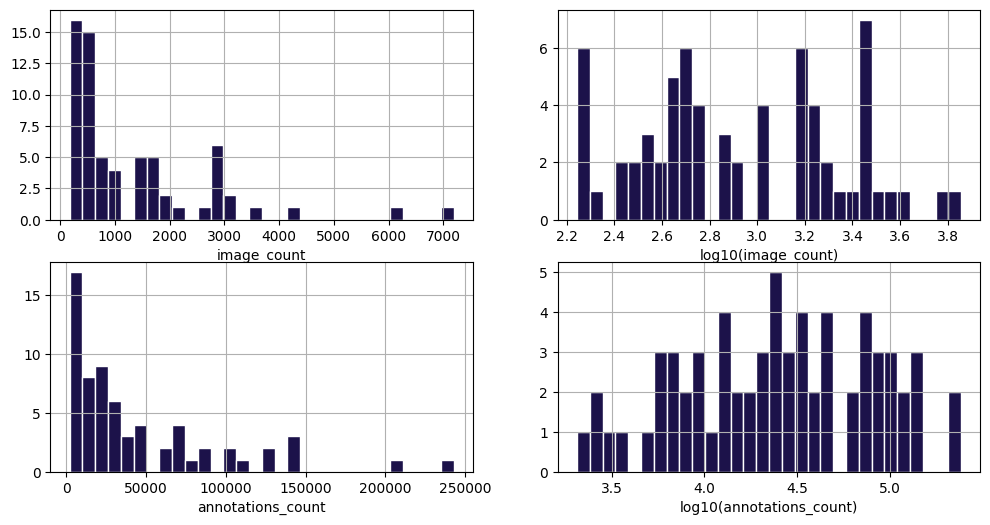

In [122]:
fig, ax = plt.subplots(figsize=(12, 6), nrows = 2, ncols = 2)
df_source["image_count"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[0,0])
ax[0, 0].set_xlabel("image_count")

np.log10(df_source["image_count"]).hist(
    bins=30, edgecolor="white", color="#1C124A", ax=ax[0, 1]
)
ax[0, 1].set_xlabel("log10(image_count)")

df_source["annotations_count"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[1,0])
ax[1,0].set_xlabel("annotations_count")

np.log10(df_source["annotations_count"]).hist(
    bins=30, edgecolor="white", color="#1C124A", ax=ax[1, 1]
)
ax[1, 1].set_xlabel("log10(annotations_count)")
plt.show()

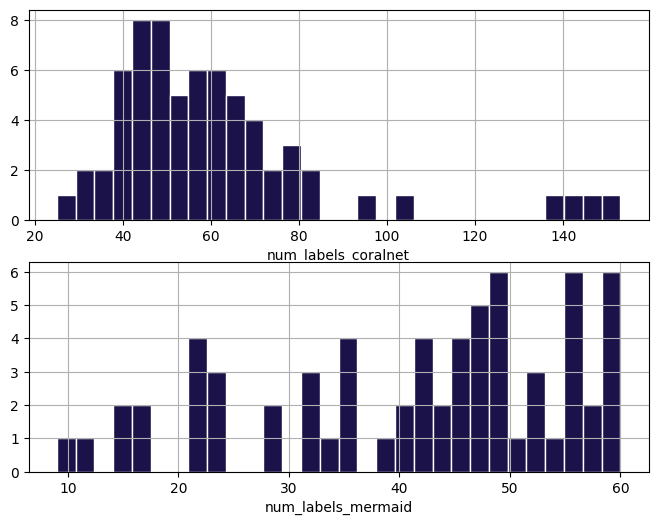

In [89]:
fig, ax = plt.subplots(figsize=(8, 6), nrows = 2)
df_source["num_labels_coralnet"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[0])
ax[0].set_xlabel("num_labels_coralnet")

df_source["num_labels_mermaid"].hist(bins=30, edgecolor="white", color="#1C124A", ax=ax[1])
ax[1].set_xlabel("num_labels_mermaid")
plt.show()

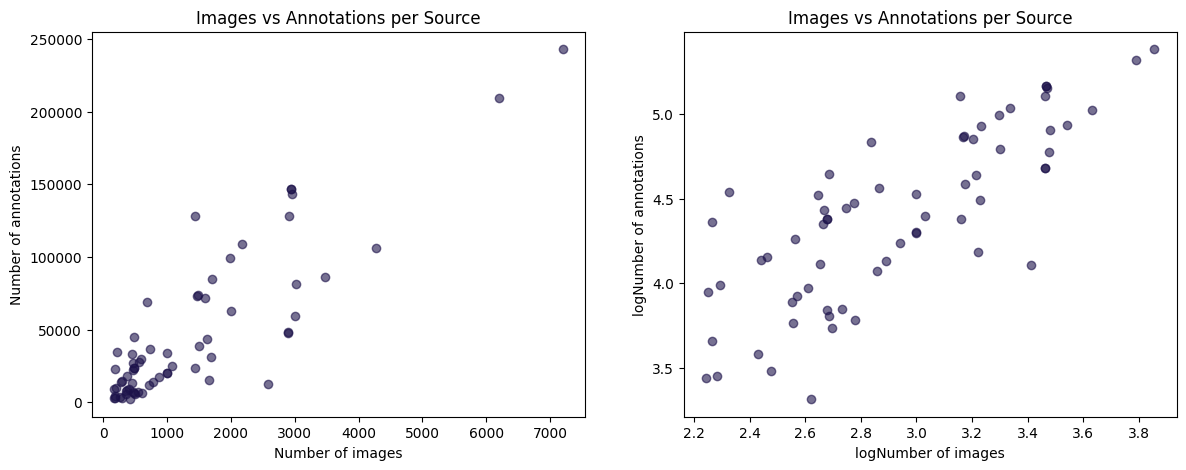

In [123]:
fig, ax = plt.subplots(figsize=(14, 5), ncols = 2)
ax[0].scatter(
    df_source["image_count"],
    df_source["annotations_count"],
    alpha=0.6,
    color="#1C124A"
)   

ax[0].set_xlabel("Number of images")
ax[0].set_ylabel("Number of annotations")
ax[0].set_title("Images vs Annotations per Source")

ax[1].scatter(
    np.log10(df_source["image_count"]),
    np.log10(df_source["annotations_count"]),
    alpha=0.6,
    color="#1C124A"
)   

ax[1].set_xlabel("logNumber of images")
ax[1].set_ylabel("logNumber of annotations")
ax[1].set_title("Images vs Annotations per Source")
plt.show()

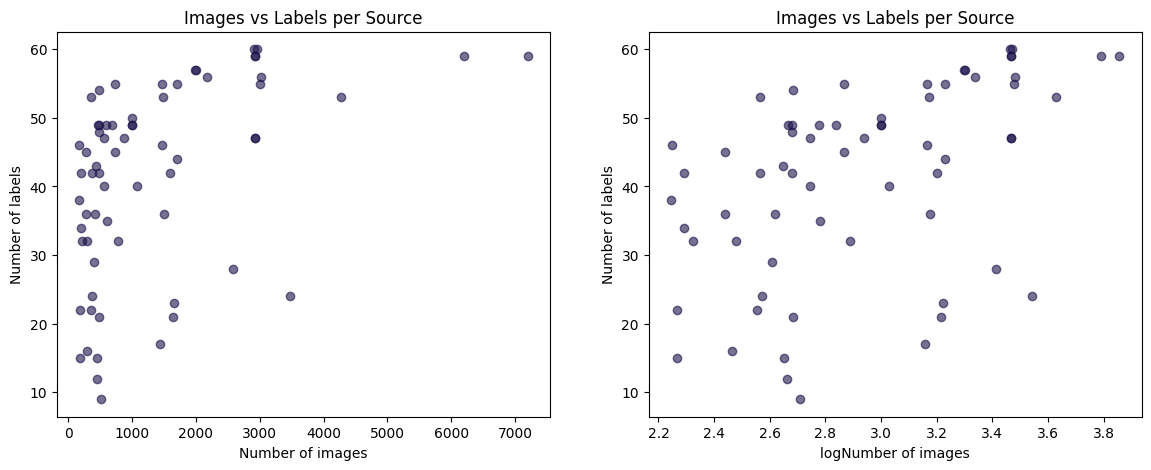

In [91]:
fig, ax = plt.subplots(figsize=(14, 5), ncols = 2)
ax[0].scatter(
    df_source["image_count"],
    df_source["num_labels_mermaid"],
    alpha=0.6,
    color="#1C124A"
)   
    
ax[0].set_xlabel("Number of images")
ax[0].set_ylabel("Number of labels")
ax[0].set_title("Images vs Labels per Source")

ax[1].scatter(
    np.log10(df_source["image_count"]),
    df_source["num_labels_mermaid"],
    alpha=0.6,
    color="#1C124A"
)   

ax[1].set_xlabel("logNumber of images")
ax[1].set_ylabel("Number of labels")
ax[1].set_title("Images vs Labels per Source")
plt.show()

# Label EDA

In [126]:
df_labels = (
    df_annotations_final
    .groupby(["target_label_name"], dropna=False)
    .agg(
        num_annotations=("target_label_name", "size"),
        num_images=("image_id", "nunique"),
        num_sources =("source_id", "nunique"),
    )
    .reset_index()
)

df_labels.head()

,target_label_name,num_annotations,num_images,num_sources
0,acanthastrea,1421,1003,38
1,acropora,226655,33709,51
2,agaricia agaricites,1899,392,7
3,algae covered substrate,31849,4188,4
4,alveopora,1172,112,16


In [127]:
df_labels.shape

(76, 4)

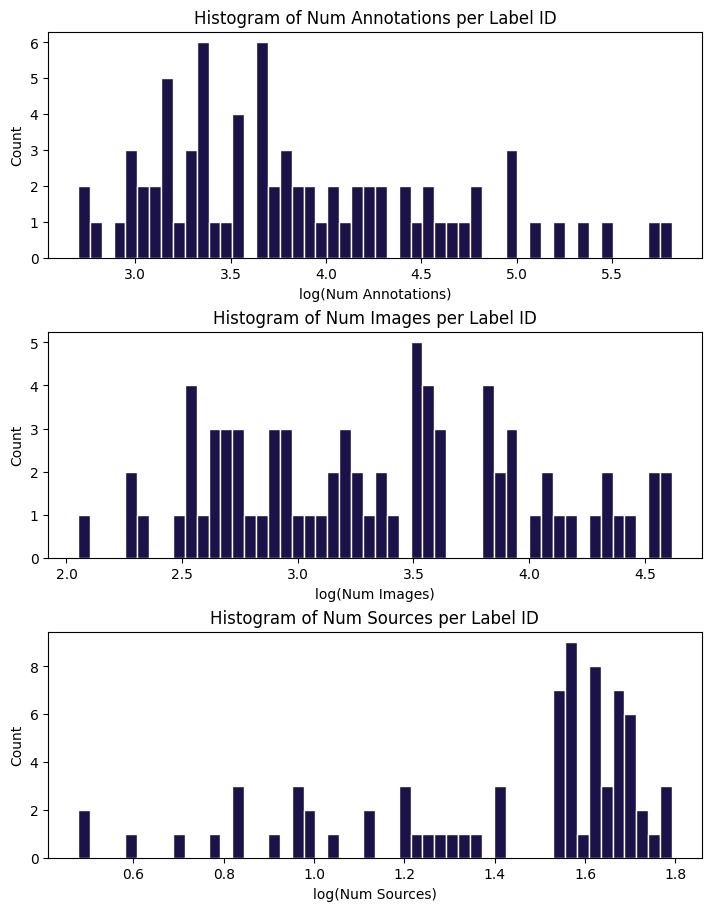

In [128]:
fig, ax = plt.subplots(figsize=(7, 9), nrows = 3, layout = "compressed")
ax[0].hist(np.log10(df_labels["num_annotations"]), bins=50, edgecolor="white", color = "#1C124A")
ax[0].set_xlabel("log(Num Annotations)")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of Num Annotations per Label ID")

ax[1].hist(np.log10(df_labels["num_images"]), bins=50, edgecolor="white", color = "#1C124A")
ax[1].set_xlabel("log(Num Images)")
ax[1].set_ylabel("Count")
ax[1].set_title("Histogram of Num Images per Label ID")

ax[2].hist(np.log10(df_labels["num_sources"]), bins=50, edgecolor="white", color = "#1C124A")
ax[2].set_xlabel("log(Num Sources)")
ax[2].set_ylabel("Count")
ax[2].set_title("Histogram of Num Sources per Label ID")

plt.show()